In [1]:
import torch
from collections import Counter
# 加载 adj 文件
adj_file = "data/nasbench101/all_nasbench101_onehot_op.adj.pt"
adjs = torch.load(adj_file, map_location="cpu")

# 计算每个图的节点数（adj 矩阵的行数）
num_nodes = [torch.tensor(adj).shape[0] for adj in adjs]

# 统计每种节点数量的图的数量
node_counts = Counter(num_nodes)

# 打印总共有多少种节点数量，以及每种节点数量对应的图数量
print("节点数量种类数:", len(node_counts))
for nodes, count in sorted(node_counts.items()):
    print(f"节点数量为 {nodes} 的图有 {count} 个")


/tmp/ipykernel_1403997/570578772.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  adjs = torch.load(adj_file, map_location="cpu")


节点数量种类数: 6
节点数量为 2 的图有 1 个
节点数量为 3 的图有 6 个
节点数量为 4 的图有 84 个
节点数量为 5 的图有 2441 个
节点数量为 6 的图有 62010 个
节点数量为 7 的图有 359082 个


In [2]:
# 加载 accuracy 文件
acc_file = 'data/nasbench101/all_nasbench101_onehot_op.validation_accuracy.pt'
acc = torch.load(acc_file, map_location="cpu")


/tmp/ipykernel_1403997/3432211440.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  acc = torch.load(acc_file, map_location="cpu")


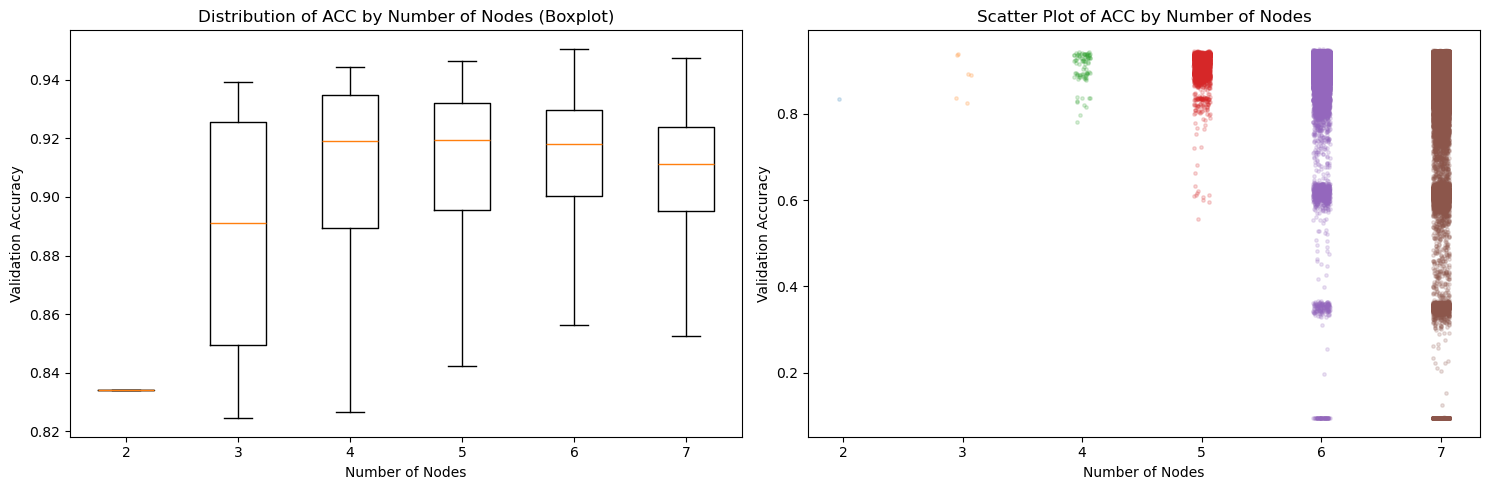

 Num | Samples |  Mean  |  Std   |  Q1    | Median |  Q3  
   2 |       1 | 0.8340 | 0.0000 | 0.8340 | 0.8340 | 0.8340
   3 |       6 | 0.8864 | 0.0442 | 0.8496 | 0.8910 | 0.9254
   4 |      84 | 0.9046 | 0.0369 | 0.8895 | 0.9192 | 0.9348
   5 |    2441 | 0.9102 | 0.0346 | 0.8956 | 0.9195 | 0.9322
   6 |   62010 | 0.9079 | 0.0522 | 0.9003 | 0.9182 | 0.9296
   7 |  359082 | 0.9014 | 0.0598 | 0.8953 | 0.9114 | 0.9239


In [10]:
import matplotlib.pyplot as plt
from collections import defaultdict

num_nodes = [int(torch.as_tensor(adj).shape[0]) for adj in adjs]
acc_values = [float(v) for v in torch.as_tensor(acc).reshape(-1).tolist()]

if len(num_nodes) != len(acc_values):
    raise ValueError(f"adjs数量({len(num_nodes)})和acc数量({len(acc_values)})不一致")

acc_by_nodes = defaultdict(list)
for n, a in zip(num_nodes, acc_values):
    acc_by_nodes[n].append(a)

sorted_nodes = sorted(acc_by_nodes)
plot_data = [acc_by_nodes[n] for n in sorted_nodes]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].boxplot(plot_data, labels=sorted_nodes, showfliers=False)
axes[0].set_xlabel('Number of Nodes')
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('Distribution of ACC by Number of Nodes (Boxplot)')

for i, n in enumerate(sorted_nodes, start=1):
    y = acc_by_nodes[n]
    x = (torch.rand(len(y)) - 0.5) * 0.14 + i
    axes[1].scatter(x.tolist(), y, s=6, alpha=0.18)

axes[1].set_xticks(list(range(1, len(sorted_nodes) + 1)), sorted_nodes)
axes[1].set_xlabel('Number of Nodes')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Scatter Plot of ACC by Number of Nodes')

plt.tight_layout()
plt.show()

stats = []
for n in sorted_nodes:
    t = torch.tensor(acc_by_nodes[n], dtype=torch.float32)
    q1, q2, q3 = torch.quantile(t, torch.tensor([0.25, 0.5, 0.75]))
    stats.append((n, len(t), float(t.mean()), float(t.std(unbiased=False)), float(q1), float(q2), float(q3)))

print(' Num | Samples |  Mean  |  Std   |  Q1    | Median |  Q3  ')
for n, cnt, mean, std, q1, q2, q3 in stats:
    print(f'{n:>4} | {cnt:>7} | {mean:.4f} | {std:.4f} | {q1:.4f} | {q2:.4f} | {q3:.4f}')
